# Unidad 5 · Bloque 2: Representación de datos
**Métodos de Análisis de Datos I — UNS**

---

## Contenido
1. PCA — Análisis de Componentes Principales
2. t-SNE
3. UMAP
4. LDA — Análisis Discriminante Lineal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

np.random.seed(42)
print('Librerías cargadas.')
print('Nota: UMAP requiere instalación separada (pip install umap-learn).')
print('      Si no está disponible, la sección correspondiente se omite.')

Librerías cargadas.
Nota: UMAP requiere instalación separada (pip install umap-learn).
      Si no está disponible, la sección correspondiente se omite.


---
## 1. PCA — Análisis de Componentes Principales

### Definiciones clave

> **Componente principal:** proyección lineal $\mathbf{z}_j = \mathbf{X}\mathbf{v}_j$ que maximiza la varianza, con $\mathbf{v}_j$ autovector de la matriz de covarianza muestral $\mathbf{S}$.

> **Varianza explicada** por la componente $j$: $\lambda_j / \sum_l \lambda_l$, donde $\lambda_j$ son los autovalores de $\mathbf{S}$ en orden decreciente.

> **Loading** $v_{jl}$: peso de la variable $l$ en la componente $j$. Indica cuánto "aporta" cada variable original a cada componente.

> **Score** $z_{ij}$: coordenada de la observación $i$ en la componente $j$. Es la proyección de $\mathbf{x}_i$ sobre $\mathbf{v}_j$.

> **Biplot:** gráfico que superpone scores (puntos) y loadings (flechas) en el mismo espacio. Permite interpretar conjuntamente la posición de las observaciones y el rol de cada variable.

In [2]:
# Dataset: Iris (4 variables, 3 especies, 150 observaciones)
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
nombres_iris = iris.target_names
vars_iris = ['Sépalo largo', 'Sépalo ancho', 'Pétalo largo', 'Pétalo ancho']

# Ajustar PCA
pca = PCA()
scores = pca.fit_transform(X_iris)
varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print('Varianza explicada por componente:')
for j, (v, va) in enumerate(zip(varianza, varianza_acum)):
    print(f'  PC{j+1}: {v*100:.2f}%  (acumulada: {va*100:.2f}%)')

Varianza explicada por componente:
  PC1: 72.96%  (acumulada: 72.96%)
  PC2: 22.85%  (acumulada: 95.81%)
  PC3: 3.67%  (acumulada: 99.48%)
  PC4: 0.52%  (acumulada: 100.00%)


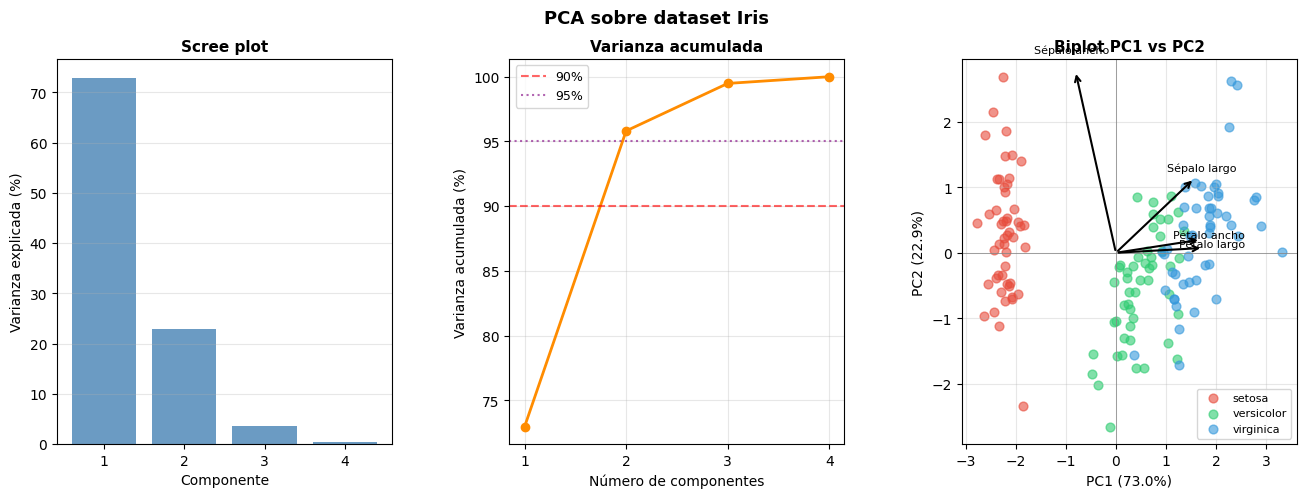

In [3]:
# Scree plot + varianza acumulada + biplot
colores_iris = ['#E74C3C', '#2ECC71', '#3498DB']

fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Scree plot
ax1.bar(range(1, 5), varianza * 100, color='steelblue', alpha=0.8)
ax1.set_xlabel('Componente'); ax1.set_ylabel('Varianza explicada (%)')
ax1.set_title('Scree plot', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(range(1, 5))

# Varianza acumulada
ax2.plot(range(1, 5), varianza_acum * 100, 'o-', color='darkorange', linewidth=2)
ax2.axhline(90, color='red', linestyle='--', alpha=0.6, label='90%')
ax2.axhline(95, color='purple', linestyle=':', alpha=0.6, label='95%')
ax2.set_xlabel('Número de componentes'); ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_title('Varianza acumulada', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 5))

# Biplot PC1 vs PC2
for i, (sp, color) in enumerate(zip(nombres_iris, colores_iris)):
    mask = y_iris == i
    ax3.scatter(scores[mask, 0], scores[mask, 1], c=color, alpha=0.6, s=40, label=sp)
loadings = pca.components_[:2].T
scale = 3
for j, var in enumerate(vars_iris):
    ax3.annotate('', xy=(loadings[j, 0]*scale, loadings[j, 1]*scale), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax3.text(loadings[j, 0]*scale*1.1, loadings[j, 1]*scale*1.1, var, fontsize=8, ha='center')
ax3.axhline(0, color='gray', lw=0.5); ax3.axvline(0, color='gray', lw=0.5)
ax3.set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
ax3.set_title('Biplot PC1 vs PC2', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.suptitle('PCA sobre dataset Iris', fontsize=13, fontweight='bold')
plt.show()

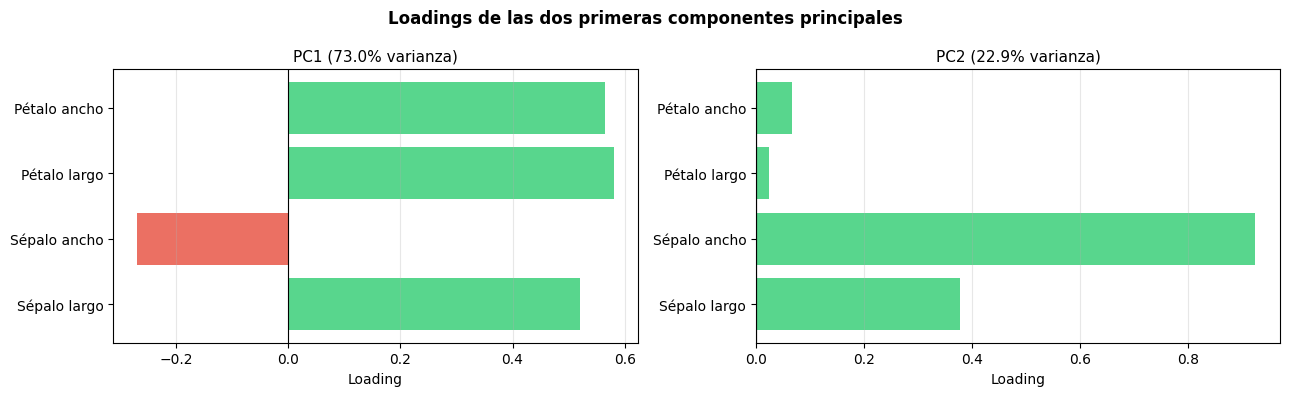

PC1 está dominada por variables de pétalo (largo y ancho): separa setosa del resto.
PC2 está dominada por el ancho de sépalo: separa versicolor de virginica.


In [4]:
# Loadings: qué variables contribuyen a cada componente
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pc_idx in zip(axes, [0, 1]):
    loads = pca.components_[pc_idx]
    colores_bar = ['#E74C3C' if l < 0 else '#2ECC71' for l in loads]
    ax.barh(vars_iris, loads, color=colores_bar, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Loading')
    ax.set_title(f'PC{pc_idx+1} ({varianza[pc_idx]*100:.1f}% varianza)', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Loadings de las dos primeras componentes principales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('PC1 está dominada por variables de pétalo (largo y ancho): separa setosa del resto.')
print('PC2 está dominada por el ancho de sépalo: separa versicolor de virginica.')

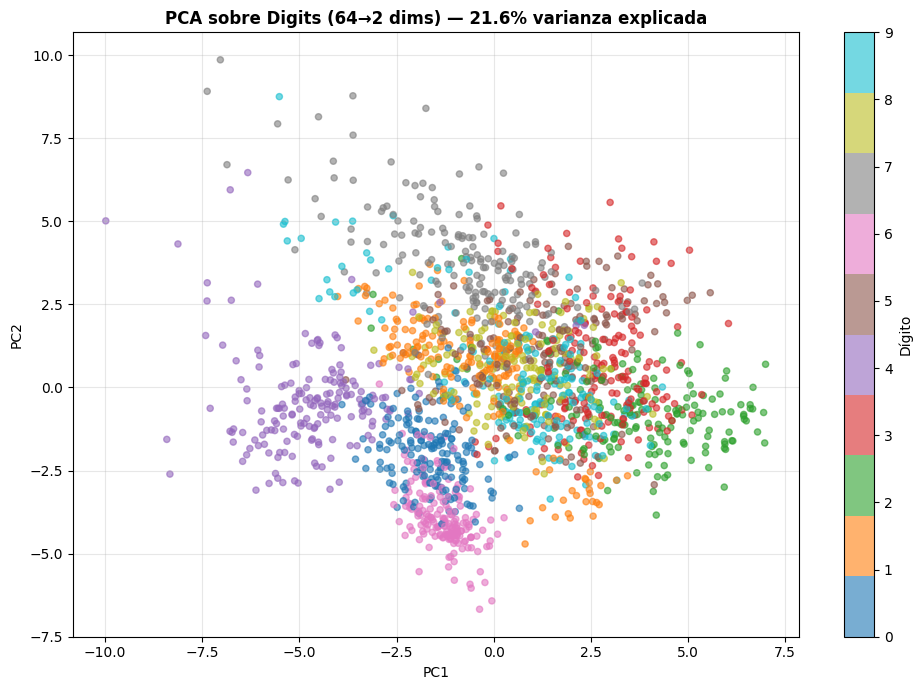

Con solo 2 componentes se retiene el 21.6% de la varianza de 64 dimensiones.


In [5]:
# PCA en alta dimensión: dataset Digits (64 variables -> 2 componentes para visualizar)
digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data)
y_dig = digits.target

pca_dig = PCA(n_components=2)
scores_dig = pca_dig.fit_transform(X_dig)
var_exp = pca_dig.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(scores_dig[:, 0], scores_dig[:, 1], c=y_dig,
                     cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, ax=ax, label='Dígito')
ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
ax.set_title(f'PCA sobre Digits (64→2 dims) — {var_exp*100:.1f}% varianza explicada',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Con solo 2 componentes se retiene el {var_exp*100:.1f}% de la varianza de 64 dimensiones.')

---
## 2. t-SNE

### Definiciones clave

> **t-SNE (t-Distributed Stochastic Neighbor Embedding):** técnica de reducción no lineal que modela similitudes entre puntos con gaussianas en alta dimensión ($p_{ij}$) y con una distribución $t$ de Student en baja dimensión ($q_{ij}$), minimizando la divergencia KL entre ambas distribuciones.

> **Perplejidad:** parámetro que controla cuántos vecinos se consideran "cercanos". Equivale aproximadamente al número efectivo de vecinos. Valores típicos: 5–50. Perplejidad baja → estructura muy local; perplejidad alta → más estructura global.

> **Advertencia clave:** las distancias *entre* clusters en t-SNE **no son interpretables**. Dos clusters que aparecen lejos en el mapa pueden estar cerca en el espacio original. Solo la estructura *interna* de cada cluster es confiable.

Ajustando t-SNE sobre Digits...


Listo.


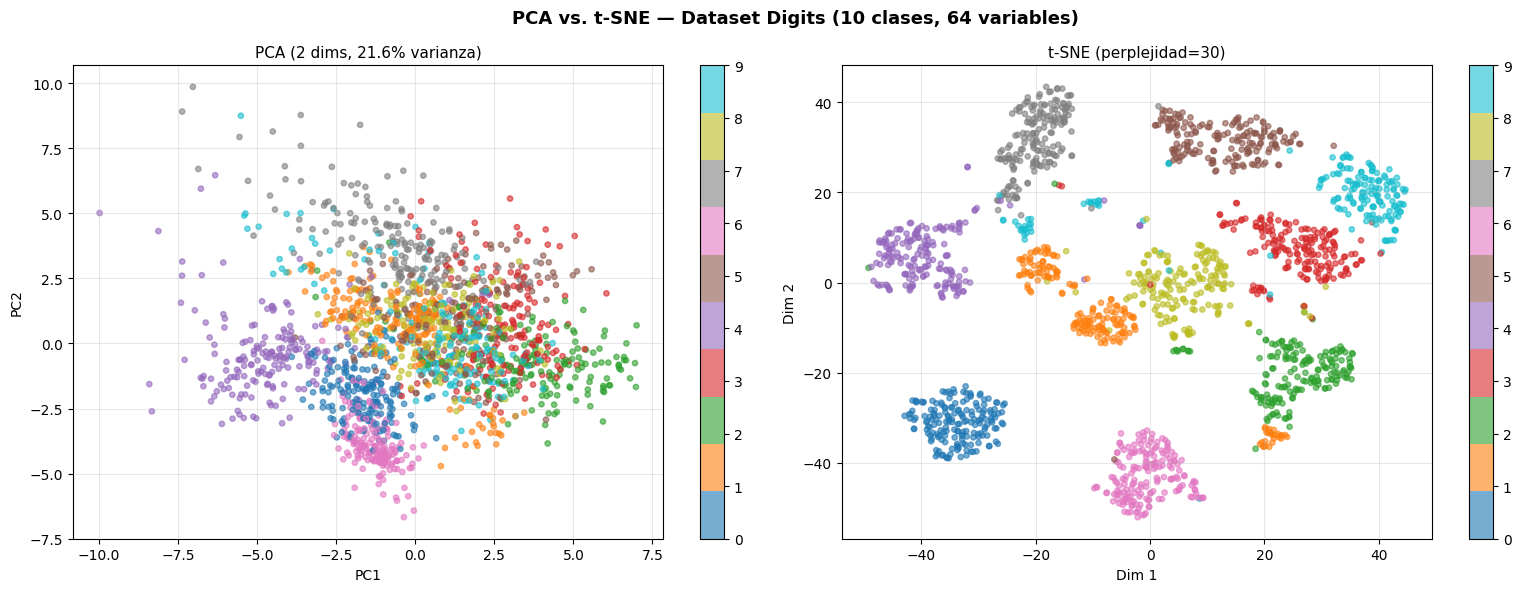

t-SNE separa los 10 dígitos mucho mejor que PCA.
Pero las distancias entre clusters en t-SNE no son interpretables.


In [6]:
# t-SNE sobre Digits: 64 dimensiones -> 2
# (puede tardar 1-2 minutos con n=1797)
print('Ajustando t-SNE sobre Digits...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb_tsne = tsne.fit_transform(X_dig)
print('Listo.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
sc1 = axes[0].scatter(scores_dig[:, 0], scores_dig[:, 1], c=y_dig,
                      cmap='tab10', alpha=0.6, s=15)
axes[0].set_title(f'PCA (2 dims, {var_exp*100:.1f}% varianza)', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0])
axes[0].grid(True, alpha=0.3)

# t-SNE
sc2 = axes[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=y_dig,
                      cmap='tab10', alpha=0.6, s=15)
axes[1].set_title('t-SNE (perplejidad=30)', fontsize=11)
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
plt.colorbar(sc2, ax=axes[1])
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs. t-SNE — Dataset Digits (10 clases, 64 variables)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('t-SNE separa los 10 dígitos mucho mejor que PCA.')
print('Pero las distancias entre clusters en t-SNE no son interpretables.')

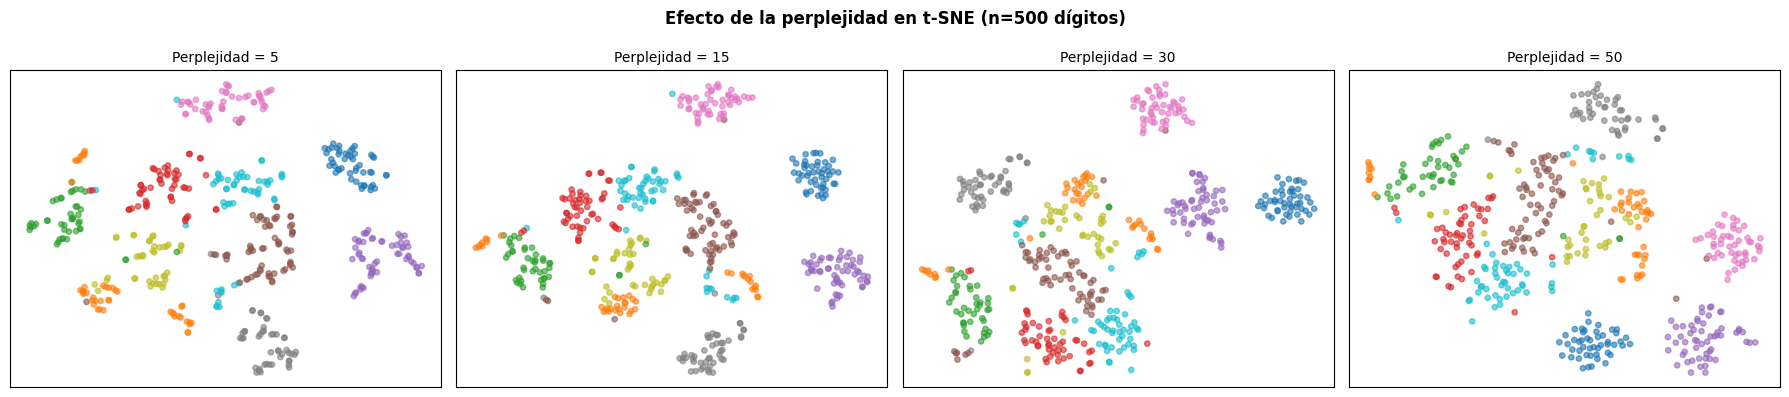

In [7]:
# Efecto de la perplejidad en t-SNE
# (muestra una muestra de 500 puntos para ser más rápido)
idx = np.random.choice(len(X_dig), 500, replace=False)
X_sub, y_sub = X_dig[idx], y_dig[idx]

perpleji = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, perpleji):
    emb = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=500).fit_transform(X_sub)
    ax.scatter(emb[:, 0], emb[:, 1], c=y_sub, cmap='tab10', alpha=0.6, s=15)
    ax.set_title(f'Perplejidad = {perp}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Efecto de la perplejidad en t-SNE (n=500 dígitos)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. UMAP

### Definiciones clave

> **UMAP (Uniform Manifold Approximation and Projection):** método de reducción no lineal basado en geometría diferencial y topología algebraica. Construye un grafo de vecindad en alta dimensión y optimiza una representación de baja dimensión que preserve la estructura del grafo.

> **`n_neighbors`:** cantidad de vecinos usados para construir el grafo. Valores bajos → estructura muy local; valores altos → más estructura global. Típico: 5–50.

> **`min_dist`:** distancia mínima entre puntos en el embedding. Valores bajos → clusters más compactos; valores altos → más dispersión. Típico: 0.0–0.5.

> **Ventajas sobre t-SNE:** más rápido, preserva mejor la estructura global, determinístico con semilla fija, proyectable (puede transformar nuevas observaciones).

In [8]:
try:
    import umap
    UMAP_DISPONIBLE = True
    print('UMAP disponible.')
except ImportError:
    UMAP_DISPONIBLE = False
    print('UMAP no instalado. Instalar con: pip install umap-learn')
    print('La siguiente celda mostrará una comparación simulada con t-SNE.')

if UMAP_DISPONIBLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb_umap = reducer.fit_transform(X_dig)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc1 = axes[0].scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=y_dig, cmap='tab10', alpha=0.6, s=15)
    axes[0].set_title('t-SNE (perplejidad=30)', fontsize=11)
    plt.colorbar(sc1, ax=axes[0])
    axes[0].grid(True, alpha=0.3)

    sc2 = axes[1].scatter(emb_umap[:, 0], emb_umap[:, 1], c=y_dig, cmap='tab10', alpha=0.6, s=15)
    axes[1].set_title('UMAP (n_neighbors=15, min_dist=0.1)', fontsize=11)
    plt.colorbar(sc2, ax=axes[1])
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('t-SNE vs UMAP — Digits', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    # Mostrar variación de parámetros t-SNE como aproximación
    print('Mostrando t-SNE con distintos parámetros como referencia.')

UMAP no instalado. Instalar con: pip install umap-learn
La siguiente celda mostrará una comparación simulada con t-SNE.
Mostrando t-SNE con distintos parámetros como referencia.


---
## 4. LDA — Análisis Discriminante Lineal

### Definiciones clave

> **Criterio de Fisher:** maximiza el cociente de Rayleigh $J(\mathbf{w}) = \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}$, donde $\mathbf{S}_B$ es la dispersión *entre* clases y $\mathbf{S}_W$ la dispersión *dentro* de clases.

> **Dimensiones discriminantes:** los autovectores de $\mathbf{S}_W^{-1}\mathbf{S}_B$. Con $k$ clases se pueden extraer hasta $\min(k-1, p)$ dimensiones.

> **LDA vs PCA:**  
> - PCA maximiza la varianza total, **ignorando** las etiquetas de clase.  
> - LDA maximiza la separabilidad entre clases, **usando** las etiquetas. Es supervisado.

> **Supuesto de LDA:** las distribuciones de cada clase son gaussianas con la misma matriz de covarianza (homocedasticidad).

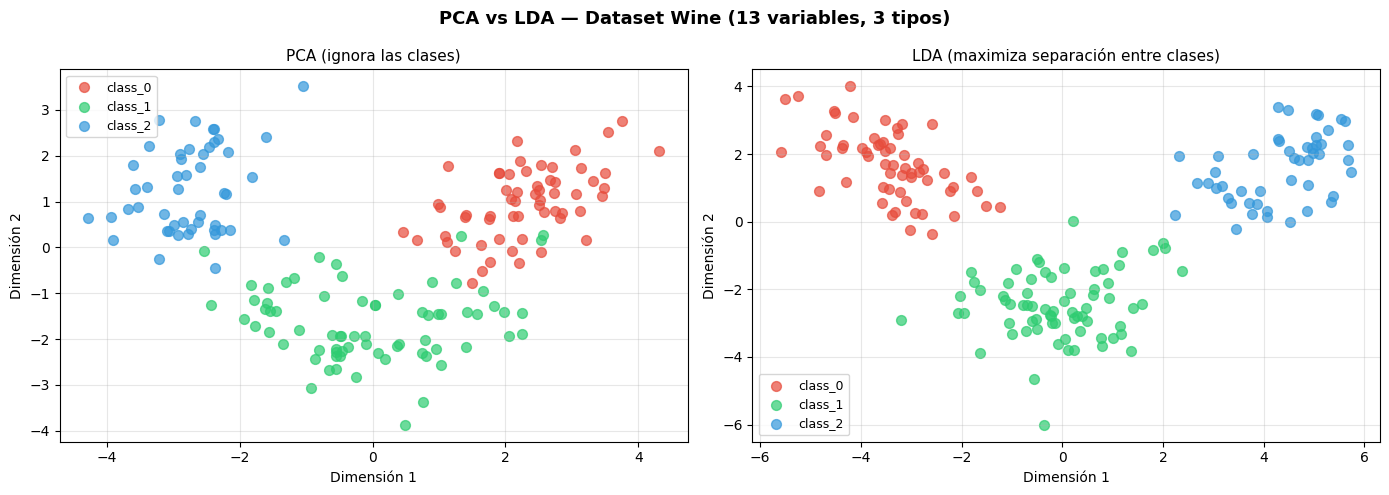

LDA separa los tres tipos de vino casi perfectamente en 2D.
PCA los mezcla más porque no usa la información de clase.


In [9]:
# LDA sobre Wine: 13 variables químicas, 3 tipos de vino
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)
y_wine = wine.target
nombres_wine = wine.target_names

lda = LinearDiscriminantAnalysis(n_components=2)
scores_lda = lda.fit_transform(X_wine, y_wine)

pca_wine = PCA(n_components=2)
scores_pca_wine = pca_wine.fit_transform(X_wine)

colores_wine = ['#E74C3C', '#2ECC71', '#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, titulo in zip(axes,
                               [scores_pca_wine, scores_lda],
                               ['PCA (ignora las clases)', 'LDA (maximiza separación entre clases)']):
    for i, (nombre, color) in enumerate(zip(nombres_wine, colores_wine)):
        mask = y_wine == i
        ax.scatter(scores[mask, 0], scores[mask, 1], c=color, alpha=0.7, s=50, label=nombre)
    ax.set_xlabel('Dimensión 1'); ax.set_ylabel('Dimensión 2')
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('PCA vs LDA — Dataset Wine (13 variables, 3 tipos)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('LDA separa los tres tipos de vino casi perfectamente en 2D.')
print('PCA los mezcla más porque no usa la información de clase.')

Varianza explicada por los discriminantes LDA:
  LD1: 68.75%
  LD2: 31.25%


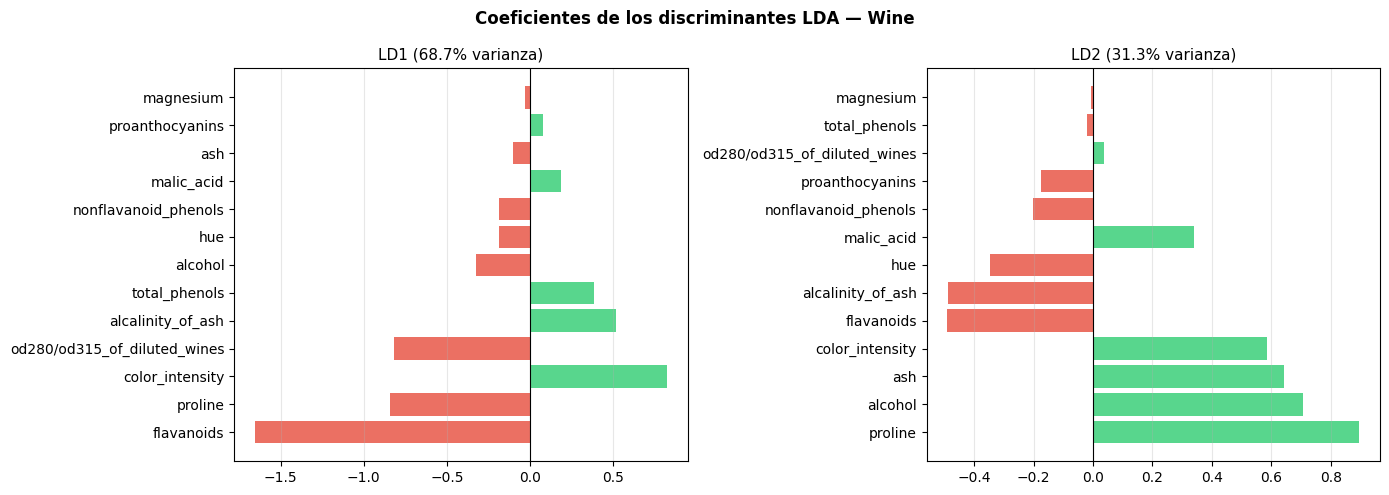

In [10]:
# Varianza explicada por los discriminantes de LDA
varianza_lda = lda.explained_variance_ratio_
print('Varianza explicada por los discriminantes LDA:')
for j, v in enumerate(varianza_lda):
    print(f'  LD{j+1}: {v*100:.2f}%')

# Importancia de variables: coeficientes de los discriminantes
vars_wine = wine.feature_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ld_idx in zip(axes, [0, 1]):
    coefs = lda.coef_[ld_idx] if lda.coef_.shape[0] > 1 else lda.coef_[0]
    coefs = lda.scalings_[:, ld_idx]
    orden = np.argsort(np.abs(coefs))[::-1]
    colores_bar = ['#E74C3C' if c < 0 else '#2ECC71' for c in coefs[orden]]
    ax.barh([vars_wine[i] for i in orden], coefs[orden], color=colores_bar, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'LD{ld_idx+1} ({varianza_lda[ld_idx]*100:.1f}% varianza)', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Coeficientes de los discriminantes LDA — Wine', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

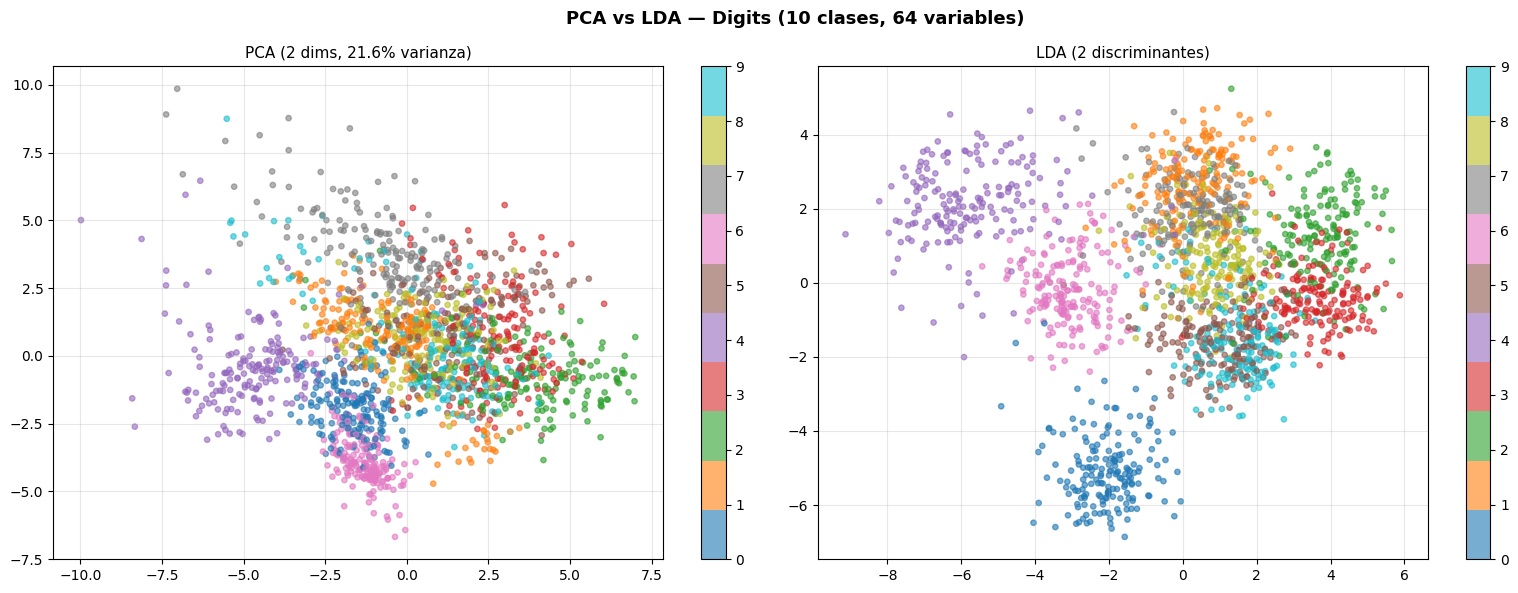

LDA extrae 9 discriminantes (min(10-1, 64) = 9).
Los dos primeros ya separan las 10 clases mucho mejor que PCA.


In [11]:
# LDA sobre Digits: 64 variables -> 9 discriminantes (10 clases -> min(9, 64) = 9)
lda_dig = LinearDiscriminantAnalysis()
scores_lda_dig = lda_dig.fit_transform(X_dig, y_dig)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(scores_dig[:, 0], scores_dig[:, 1], c=y_dig,
                      cmap='tab10', alpha=0.6, s=15)
axes[0].set_title(f'PCA (2 dims, {var_exp*100:.1f}% varianza)', fontsize=11)
plt.colorbar(sc1, ax=axes[0])
axes[0].grid(True, alpha=0.3)

sc2 = axes[1].scatter(scores_lda_dig[:, 0], scores_lda_dig[:, 1], c=y_dig,
                      cmap='tab10', alpha=0.6, s=15)
axes[1].set_title('LDA (2 discriminantes)', fontsize=11)
plt.colorbar(sc2, ax=axes[1])
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs LDA — Digits (10 clases, 64 variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'LDA extrae {lda_dig.scalings_.shape[1]} discriminantes (min(10-1, 64) = 9).')
print('Los dos primeros ya separan las 10 clases mucho mejor que PCA.')

---
## Resumen del bloque

| Método | Transformación | Estructura preservada | Supervisado | Uso típico |
|--------|---------------|----------------------|-------------|------------|
| PCA | Lineal | Global (varianza) | No | Preprocesamiento, exploración |
| t-SNE | No lineal | Local | No | Visualización 2D |
| UMAP | No lineal | Local + global | No | Visualización, preprocesamiento |
| LDA | Lineal | Separabilidad entre clases | Sí | Exploración supervisada, clasificación |

**Pipeline recomendado:**
1. Estandarizar.
2. PCA para reducir dimensión y eliminar colinealidad.
3. UMAP o t-SNE para visualización exploratoria.
4. LDA si hay etiquetas y se quiere evaluar separabilidad.

## Conclusiones - Reduccion de Dimensionalidad

## Analisis de Tecnicas de Reduccion Dimensional

### Metodos explorados:

1. **PCA (Analisis de Componentes Principales)**:
   - Lineal, preserva maxima varianza
   - Velocidad: muy rapida
   - Interpretabilidad: excelente (componentes principales)
   - Desventaja: no preserva estructura local

2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**:
   - No lineal, preserva estructura local
   - Excelente visualizacion de clusters
   - Puede ser lenta en datasets grandes
   - Desventaja: distancias no interpretables, computacionalmente costosa

3. **UMAP (Uniform Manifold Approximation and Projection)**:
   - No lineal, mas rapido que t-SNE
   - Preserva mejor la estructura global
   - Escala mejor a datasets grandes
   - Equilibrio entre velocidad e interpretabilidad

### Cuando usar cada uno:
- Exploracion inicial → PCA
- Visualizacion de clusters → t-SNE o UMAP
- Datasets grandes → UMAP
- Machine learning posterior → PCA o componentes de UMAP

### Parametros criticos:
- PCA: n_components (varianza explicada)
- t-SNE: perplejidad (recomendado 30-50)
- UMAP: n_neighbors, min_dist